# 🔋 Phase 1: Ekstraksi Parameter ECM dari Uji HPPC (Hybrid Pulse Power Characterization)

**Tujuan Eksperimen:**
Mengidentifikasi parameter dinamis baterai LiFePO4 berdasarkan *Equivalent Circuit Model* (ECM) Orde-1, yang meliputi:
1. $R_0$ (Hambatan Ohmic / *Internal Resistance* murni)
2. $R_1$ (Hambatan Polarisasi)
3. $C_1$ (Kapasitansi Polarisasi)
Parameter ini diekstrak pada setiap interval 10% *State of Charge* (SoC) mulai dari 90% hingga 0%.

**Dataset Input (Digabung secara Sekuensial):**
1. `charge-rest 60m.csv` (Fase inisialisasi: Pengisian penuh hingga 3.65V dan relaksasi 60 menit)
2. `hppc (loop10x).csv` (Fase pengujian utama: 10 siklus *pulse discharge* dengan interval istirahat)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# Konfigurasi Tampilan Plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)

# =========================================================
# 1. FUNGSI PEMBACA DAN PENGGABUNG DATA (DATA STITCHING)
# =========================================================
def load_zke_data(filepath):
    skip_rows = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if "Time(S)" in line:
                skip_rows = i
                break
    df = pd.read_csv(filepath, skiprows=skip_rows)
    df.columns = [col.strip() for col in df.columns]
    return df

# Memuat kedua file
df_prep = load_zke_data("charge-rest 60m.csv")
df_hppc = load_zke_data("hppc (loop10x).csv")

# Mengakomodasi selisih waktu saat mengganti konfigurasi alat (misal: 60 detik)
jeda_waktu_antar_tes = 60 
waktu_terakhir_prep = df_prep['Time(S)'].iloc[-1]

# Menyelaraskan sumbu waktu file kedua agar bersambung dari file pertama
df_hppc['Time(S)'] = df_hppc['Time(S)'] + waktu_terakhir_prep + jeda_waktu_antar_tes

# Menggabungkan kedua dataframe menjadi satu kesatuan (Timeline berurutan)
df_combined = pd.concat([df_prep, df_hppc], ignore_index=True)

print("✅ Data berhasil digabungkan!")
print(f"Total Baris Data: {len(df_combined)}")
print(f"Total Durasi Pengujian: {df_combined['Time(S)'].iloc[-1] / 3600:.2f} Jam")

✅ Data berhasil digabungkan!
Total Baris Data: 33139
Total Durasi Pengujian: 18.39 Jam


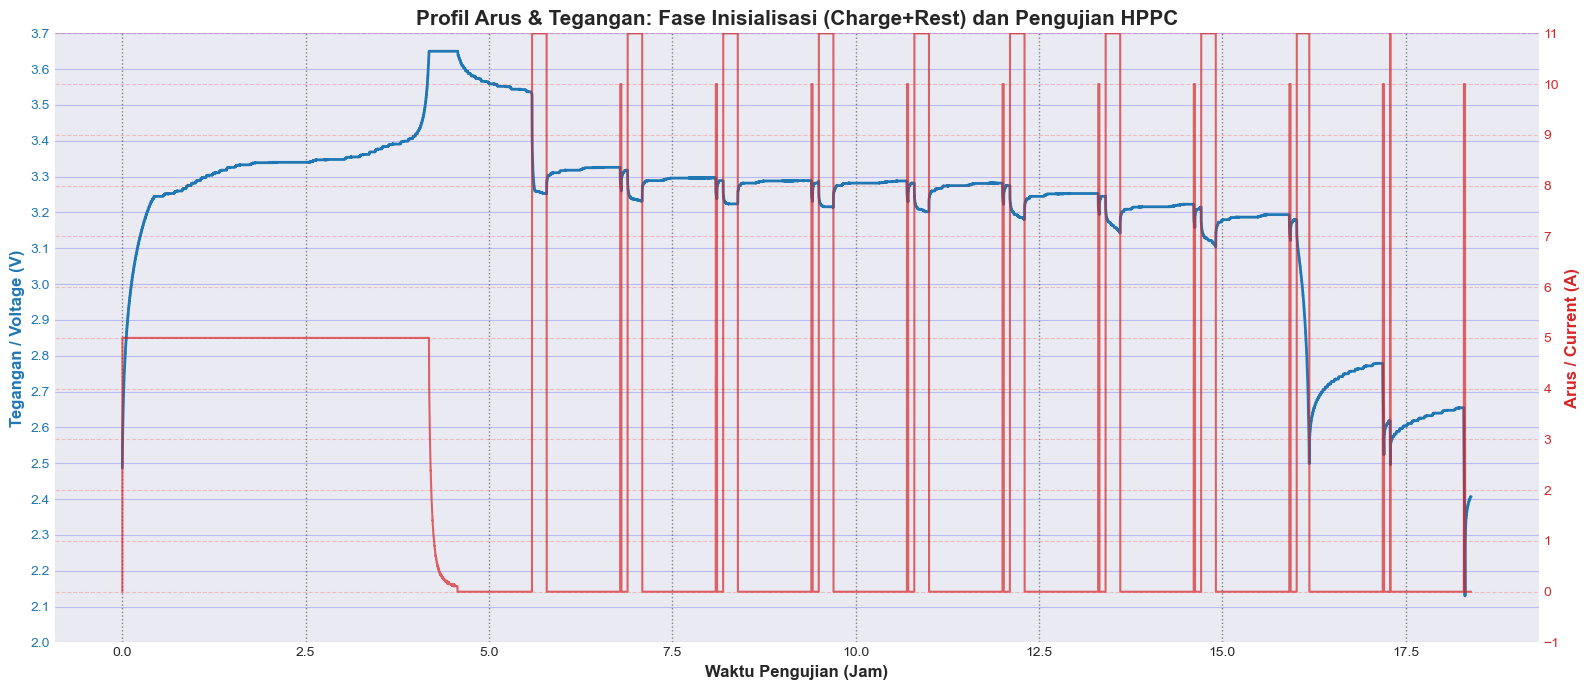

In [2]:
# =========================================================
# 2. VISUALISASI PROFIL DATA MENTAH GABUNGAN
# =========================================================
fig, ax1 = plt.subplots(figsize=(16, 7))
waktu_jam = df_combined['Time(S)'] / 3600.0

# Plot Tegangan (Voltage) - Sumbu Y Kiri (Warna Biru)
color_v = 'tab:blue'
ax1.set_xlabel('Waktu Pengujian (Jam)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Tegangan / Voltage (V)', color=color_v, fontweight='bold', fontsize=12)
ax1.plot(waktu_jam, df_combined['Vol(V)'], color=color_v, linewidth=2, label='Tegangan (V)')
ax1.tick_params(axis='y', labelcolor=color_v)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_ylim(2.0, 3.7)

# Plot Arus (Current) - Sumbu Y Kanan (Warna Merah)
ax2 = ax1.twinx()  
color_c = 'tab:red'
ax2.set_ylabel('Arus / Current (A)', color=color_c, fontweight='bold', fontsize=12)
ax2.plot(waktu_jam, df_combined['Cur(A)'], color=color_c, linewidth=1.5, alpha=0.7, label='Arus (A)')
ax2.tick_params(axis='y', labelcolor=color_c)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax2.set_ylim(-1.0, 11.0) # Arus HPPC maksimal 10A

# Grid dan Layout
ax1.grid(True, which='major', axis='y', linestyle='-', linewidth=0.8, color='blue', alpha=0.2)
ax2.grid(True, which='major', axis='y', linestyle='--', linewidth=0.8, color='red', alpha=0.2)
ax1.grid(True, which='major', axis='x', linestyle=':', linewidth=1.0, color='gray')

plt.title('Profil Arus & Tegangan: Fase Inisialisasi (Charge+Rest) dan Pengujian HPPC', fontweight='bold', fontsize=15)
fig.tight_layout()
plt.show()

### 3. Ekstraksi Parameter ECM ($R_0, R_1, C_1$) via Non-linear Curve Fitting

Dari visualisasi di atas, pengujian HPPC terdiri dari siklus berulang (10x). Algoritma di bawah ini akan mendeteksi secara otomatis kapan *pulse discharge* (arus sekitar 10A) terjadi, lalu melakukan *curve fitting* pada respon tegangan pemulihan (*relaxation voltage*).

**Model Matematika Tegangan Polarisasi (Thevenin Orde-1):**
$$V_{terminal}(t) = OCV - I \cdot R_0 - I \cdot R_1 \left(1 - e^{\frac{-t}{R_1 C_1}}\right)$$

In [ ]:
# =========================================================
# 3. IDENTIFIKASI PULSA DAN CURVE FITTING
# =========================================================
# Deteksi transisi arus (Pulsa HPPC di set pada 10A, kita beri toleransi 9.0A - 10.5A)
is_pulse = (df_combined['Cur(A)'] > 9.0) & (df_combined['Cur(A)'] < 10.5)

# Mencari indeks awal dan akhir setiap pulsa
pulse_starts = df_combined.index[is_pulse.astype(int).diff() == 1].tolist()
pulse_ends = df_combined.index[is_pulse.astype(int).diff() == -1].tolist()

results = []
# Loop sebanyak jumlah pulsa yang ditemukan (Maksimal 10 loop)
for i in range(min(len(pulse_starts), len(pulse_ends))):
    start_idx = pulse_starts[i]
    end_idx = pulse_ends[i]
    
    # Tegangan istirahat tepat sebelum pulsa dimulai (OCV sesaat)
    OCV = df_combined.loc[start_idx - 1, 'Vol(V)']
    
    # Waktu relatif (dimulai dari 0 detik untuk setiap pulsa)
    t_start = df_combined.loc[start_idx, 'Time(S)']
    t = df_combined.loc[start_idx:end_idx-1, 'Time(S)'] - t_start
    
    # Tegangan terminal selama pulsa terjadi
    V = df_combined.loc[start_idx:end_idx-1, 'Vol(V)']
    
    # Tebakan awal (Initial guess) untuk R0
    R0_guess = max((OCV - V.iloc[0]) / 10.0, 0.001)
    
    # Definisi fungsi model ECM Orde-1
    def ecm_model(t, R0, R1, C1): 
        return OCV - 10.0 * R0 - 10.0 * R1 * (1 - np.exp(-t / (R1 * C1)))
    
    try:
        # ===================================================================
        # REVISI: Batasan Fisik (Physical Bounds)
        # R0 (Ohmic Drop)  : Maksimal 20 mOhm (0.02 Ohm)
        # R1 (Polarization): Maksimal 50 mOhm (0.05 Ohm) -> Cegah nyangkut 1 Ohm!
        # C1 (Capacitance) : 100 - 100000 Farad
        # ===================================================================
        popt, _ = curve_fit(ecm_model, t, V, p0=[R0_guess, 0.01, 1000], bounds=(0, [0.02, 0.05, 100000]))
        
        # Simpan hasil (SoC diasumsikan turun 10% setiap loop)
        results.append({
            'SoC (%)': 90 - (i * 10), 
            'R0 (Ohm)': popt[0], 
            'R1 (Ohm)': popt[1], 
            'C1 (Farad)': popt[2],
            'OCV (V)': OCV
        })
    except Exception as e:
        print(f"Gagal fitting pada pulsa ke-{i+1}: {e}")

df_params = pd.DataFrame(results)

print("="*60)
print("📊 HASIL EKSTRAKSI PARAMETER HPPC (SETELAH REVISI)")
print("="*60)
display(df_params)

📊 HASIL EKSTRAKSI PARAMETER HPPC (SETELAH REVISI)


,SoC (%),R0 (Ohm),R1 (Ohm),C1 (Farad),OCV (V)
0,90,0.002792,0.005190,8591.206463,3.326
1,80,0.002965,0.003532,9944.442133,3.297
2,70,0.002881,0.003565,10288.673841,3.289
3,60,0.002948,0.003313,8639.023512,3.288
4,50,0.002889,0.003400,8279.906574,3.282
5,40,0.002586,0.003836,7638.375226,3.253
6,30,0.003189,0.004135,8499.343865,3.223
7,20,0.002978,0.005384,7056.299119,3.194
8,10,0.001751,0.050000,2047.398948,2.779
9,0,0.001230,0.050000,676.278326,2.655


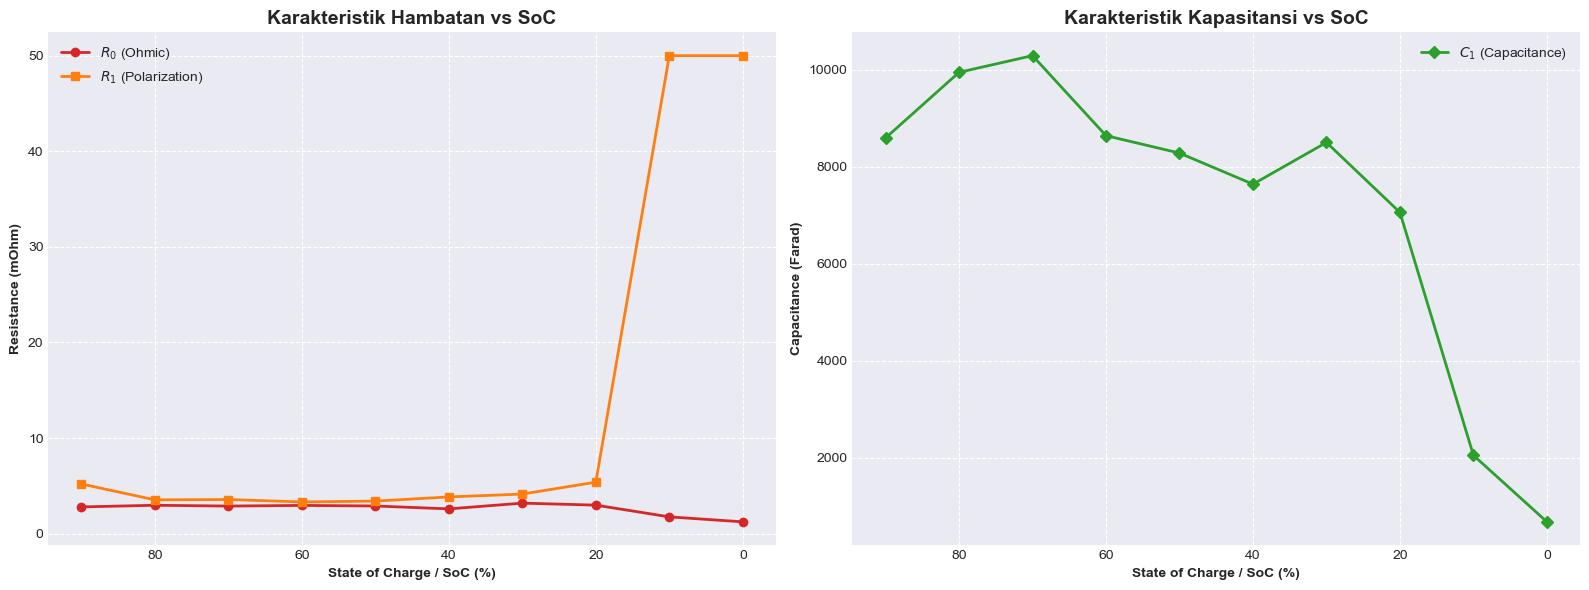

✅ Parameter ECM berhasil disimpan ke 'hppc_parameters.csv'


In [4]:
# =========================================================
# 4. VISUALISASI PARAMETER TERHADAP SOC
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot R0 dan R1
ax1.plot(df_params['SoC (%)'], df_params['R0 (Ohm)'] * 1000, marker='o', color='tab:red', linewidth=2, label='$R_0$ (Ohmic)')
ax1.plot(df_params['SoC (%)'], df_params['R1 (Ohm)'] * 1000, marker='s', color='tab:orange', linewidth=2, label='$R_1$ (Polarization)')
ax1.set_title('Karakteristik Hambatan vs SoC', fontweight='bold', fontsize=14)
ax1.set_xlabel('State of Charge / SoC (%)', fontweight='bold')
ax1.set_ylabel('Resistance (mOhm)', fontweight='bold')
ax1.invert_xaxis() # Membalik Sumbu X agar dibaca dari 90% turun ke 0%
ax1.legend()
ax1.grid(True, linestyle='--')

# Plot C1
ax2.plot(df_params['SoC (%)'], df_params['C1 (Farad)'], marker='D', color='tab:green', linewidth=2, label='$C_1$ (Capacitance)')
ax2.set_title('Karakteristik Kapasitansi vs SoC', fontweight='bold', fontsize=14)
ax2.set_xlabel('State of Charge / SoC (%)', fontweight='bold')
ax2.set_ylabel('Capacitance (Farad)', fontweight='bold')
ax2.invert_xaxis()
ax2.legend()
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# Simpan data parameter
df_params.to_csv('hppc_parameters.csv', index=False)
print("✅ Parameter ECM berhasil disimpan ke 'hppc_parameters.csv'")